# Fonts using Bezier Curves

This handout is prepared for ME310: Numerical Methods course by Atakan Aygun on Spring 25-26 semester. The main goal is to show an application of the "Interpolation" chapter using Bezier curves and font generation.

## What Are Bezier Curves, and Why Should You Care?

Every letter you're reading right now - from the elegant curve of this **"e"** to the smooth arc of an **"S"** - is defined by Bezier curves. These mathematical curves, developed by Pierre Bézier at Renault in the 1960s for designing car bodies, now power everything from the fonts on your screen to animations in your favorite video games.

Here's the fascinating part: **You only need 4 points to create any smooth curve you can imagine.** No complex equations, no storing thousands of pixel coordinates - just four strategically placed control points, and mathematics does the rest. This is why a single font file can be just a few kilobytes yet produce perfect letters at any size, from tiny mobile screens to massive billboards.

In this notebook, you'll discover:
- How simple polynomial interpolation creates these elegant curves
- Why moving a single control point can transform a straight line into a graceful arc
- How professional font designers use these curves to craft the typography you see everywhere
- The actual mathematical magic that lets your computer draw smooth curves efficiently

## The Mathematics

A **cubic Bezier curve** is defined by four control points: $P_0$ (start), $P_1$ and $P_2$ (control points), and $P_3$ (end). The curve is parametrically defined for $t \in [0,1]$ as:

$$\mathbf{B}(t) = (1-t)^3 P_0 + 3(1-t)^2 t P_1 + 3(1-t)t^2 P_2 + t^3 P_3$$

The coefficients $(1-t)^3$, $3(1-t)^2t$, $3(1-t)t^2$, and $t^3$ are called **Bernstein basis polynomials**. They ensure the curve:
- Always starts at $P_0$ (when $t=0$) and ends at $P_3$ (when $t=1$)
- Stays within the convex hull of the control points
- Is smoothly influenced by the interior control points $P_1$ and $P_2$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

# Mathematical function for Cubic Bezier
def cubic_bezier(P0, P1, P2, P3, num_points):
    """Evaluates the Bezier curve at a given resolution (num_points)."""
    t = np.linspace(0, 1, num_points)

    x = ((1-t)**3 * P0[0] + 3*(1-t)**2 * t * P1[0] + 3*(1-t) * t**2 * P2[0] + t**3 * P3[0])
    y = ((1-t)**3 * P0[1] + 3*(1-t)**2 * t * P1[1] + 3*(1-t) * t**2 * P2[1] + t**3 * P3[1])

    return x, y

## Typography with a Single Bezier Curve

The code below demonstrates how to create various letter shapes using **just one cubic Bezier curve**. Here's what each part does:

### 1. The Font Dictionary (`font_dictionary_oneCurve`)
This dictionary stores letter definitions where each letter is represented by 4 control points: `[P0, P1, P2, P3]`
- P0: Starting point of the curve
- P1: First control point (pulls the curve toward it)
- P2: Second control point (pulls the curve toward it)  
- P3: Ending point of the curve

For example, the letter 'C' is defined as:
```python
'C': [[2.0, 2.0], [-1.0, 2.0], [-1.0, 0.0], [2.0, 0.0]]
```
This creates the familiar curved shape of the letter C by cleverly positioning the control points.

### 2. The Interactive Visualization Function
The `draw_advanced_font()` function generates and displays the Bezier curve with several features:
- Plots the **control polygon** (dashed red line connecting control points)
- Draws the **actual curve** (thick blue line) by evaluating the Bezier formula at many points
- Highlights the **endpoints** in green
- Applies an **italic shear transformation** to simulate italic fonts

### 3. Interactive Sliders - Experiment and Learn!
Run the cell below and play with these sliders to understand how Bezier curves work:

- **Shape**: Select different letters to see how various control point configurations create different shapes
- **Italic Shear** (0.0 to 1.0): Applies a linear transformation $x' = x + s \cdot y$ to slant the letter (like italic fonts!)
- **Resolution** (3 to 100): Controls how many points are evaluated along the curve
  - *Low values (3-10)*: See the curve as a simple polygon approximation
  - *High values (50-100)*: Get smooth, professional-quality curves
- **P1 X/Y Tweak** (-3.0 to 3.0): Move the first control point $P_1$ and watch how it "pulls" the curve toward it
  - This is how font designers fine-tune letter shapes!

In [ ]:

# 1. The Expanded Typography Dictionary
font_dictionary_oneCurve = {
    # --- Standard Open Curves ---
    'C': [[2.0, 2.0],  [-1.0, 2.0], [-1.0, 0.0], [2.0, 0.0]],
    'U': [[0.0, 2.0],  [0.0, -1.0], [2.0, -1.0], [2.0, 2.0]],
    'J': [[0.0, 0.0], [0.0, -1.0], [2.0, -1.0], [2.0, 2.0]],

    # --- The "Pseudo-Corners" ---
    'V': [[0.0, 2.0], [0.8, -2.0], [1.2, -2.0], [2.0, 2.0]],

    # --- Complex Inflections (S-Curves) ---
    'S (Approx)': [[2.0, 2.0], [-4.0, 2.0], [6.0, 0.0], [0.0, 0.0]],
    'Wave (~)': [[0.0, 1.0], [1.0, 3.0], [1.0, -1.0], [2.0, 1.0]],

    # --- Lowercase & Stems ---
    'l (lowercase)': [[1.0, 2.0], [1.0, 0.5], [1.0, 0.0], [1.5, 0.0]],
}

# Interactive plotting function with Italic Shear
def draw_advanced_font(letter, shear_factor, num_points, P1_x_tweak, P1_y_tweak, P2_x_tweak, P2_y_tweak):
    # Fetch base points for the selected letter
    pts = np.array(font_dictionary_oneCurve[letter], dtype=float)

    # Allow to "tweak" the first control point to see the curve stretch
    pts[1][0] += P1_x_tweak
    pts[1][1] += P1_y_tweak

    # Allow to "tweak" the second control point to see the curve stretch
    pts[2][0] += P2_x_tweak
    pts[2][1] += P2_y_tweak

    P0, P1, P2, P3 = pts[0], pts[1], pts[2], pts[3]

    # Generate the curve
    curve_x, curve_y = cubic_bezier(P0, P1, P2, P3, num_points)
    poly_x, poly_y = pts[:, 0], pts[:, 1]

    # --- THE ITALIC MATH (Linear Transformation) ---
    curve_x_italic = curve_x + (shear_factor * curve_y)
    poly_x_italic = poly_x + (shear_factor * poly_y)

    # Plotting setup
    plt.figure(figsize=(8, 6))

    # Plot control polygon
    plt.plot(poly_x_italic, poly_y, 'ro--', label='Control Polygon', alpha=0.5)

    # Plot actual font curve
    plt.plot(curve_x_italic, curve_y, 'b-', linewidth=5, label=f'Font Curve ({num_points} pts)')

    # Highlight endpoints
    plt.plot([poly_x_italic[0], poly_x_italic[3]], [poly_y[0], poly_y[3]], 'gs', markersize=8, label='Endpoints')

    plt.title(f"Typography Engine: Shape '{letter}'", fontsize=14)
    plt.xlim(-5, 7) # Widened slightly to accommodate the loop and S-curve
    plt.ylim(-3, 5) # Heightened slightly to accommodate the teardrop O
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.legend()
    plt.show()

# Launch the interactive widget
print("Typography Sandbox: Select shapes, apply italics, and test resolution!")
interact(draw_advanced_font,
         letter=Dropdown(options=list(font_dictionary_oneCurve.keys()), value='C', description='Shape:'),
         shear_factor=FloatSlider(value=0.0, min=-0.5, max=1.0, step=0.1, description='Italic Shear:'),
         num_points=IntSlider(value=100, min=3, max=100, step=1, description='Resolution:'),
         P1_x_tweak=FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description='P1 X Tweak:'),
         P1_y_tweak=FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description='P1 Y Tweak:'),
         P2_x_tweak=FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description='P2 X Tweak:'),
         P2_y_tweak=FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description='P2 Y Tweak:'));

Typography Sandbox: Select shapes, apply italics, and test resolution!


interactive(children=(Dropdown(description='Shape:', options=('C', 'U', 'J', 'V', 'S (Approx)', 'Wave (~)', 'l…

## The Limitation: When One Curve Isn't Enough

While a single cubic Bezier curve can create simple letters like 'C', 'U', or 'J', it has significant limitations:

### What a Single Curve Cannot Do:
- ❌ **Closed loops**: You can't create a perfect circle or 'O' because the curve must start and end at different points
- ❌ **Multiple strokes**: Letters like 'B', 'P', or 'R' have a stem plus separate curved sections
- ❌ **Sharp corners**: While you can approximate corners (like the 'V' above), you can't create truly sharp vertices
- ❌ **Complex topology**: Shapes like the infinity symbol (∞) or figure-8 require self-intersections

### Composite Bezier Curves

Professional fonts solve this by **chaining multiple Bezier curves together**. Each curve's endpoint $P_3$ becomes the starting point $P_0$ of the next curve, creating a continuous path called a **Bezier spline**.

To make the connection look smooth (not jagged), adjacent curves must maintain continuity:
- **C0 continuity** (Positional): The end of one curve touches the start of the next → $P_3^{(i)} = P_0^{(i+1)}$
- **C1 continuity** (Tangent): The curves have the same direction at the joint → no sharp kink
- **C2 continuity** (Curvature): The rate of bending is also smooth → perfectly fluid transition

The next cell demonstrates letters built from multiple curves:
- **Letter 'B'**: 3 curves (vertical stem + two rounded lobes)
- **Letter 'O'**: 4 curves forming a perfect circle using the magic ratio 0.55228
- **Infinity symbol**: 2 curves creating the iconic ∞ shape with self-intersection
- **Letter 'M'**: 4 curves forming the sharp peaks and valleys

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

# Each letter is now a LIST of curves.
# Each curve is a list of 4 control points: [P0, P1, P2, P3]
font_dictionary_multipleCurves = {
    # The Letter 'B': A straight stem and two curved lobes.
    # Notice how the stem connects perfectly to the top lobe at (-1, 2).
    'B': [
        [[-1.0, -2.0], [-1.0, 0.0], [-1.0, 0.0], [-1.0, 2.0]], # Straight stem
        [[-1.0, 2.0], [2.5, 2.0], [2.5, 0.0], [-1.0, 0.0]],    # Top lobe
        [[-1.0, 0.0], [3.0, 0.0], [3.0, -2.0], [-1.0, -2.0]]   # Bottom lobe
    ],

    # A nearly perfect 'O' (Circle) using 4 Bezier curves.
    # The magical offset for a circle is radius * 0.55228
    'O (Perfect)': [
        [[0.0, 2.0], [1.104, 2.0], [2.0, 1.104], [2.0, 0.0]],   # Top Right quadrant
        [[2.0, 0.0], [2.0, -1.104], [1.104, -2.0], [0.0, -2.0]],# Bottom Right quadrant
        [[0.0, -2.0], [-1.104, -2.0], [-2.0, -1.104], [-2.0, 0.0]], # Bottom Left quadrant
        [[-2.0, 0.0], [-2.0, 1.104], [-1.104, 2.0], [0.0, 2.0]] # Top Left quadrant
    ],

    # The Infinity Symbol: Two intersecting loops made of 2 curves.
    # Watch the C1 continuity at the origin (0,0) where the loops meet.
    'Infinity': [
        [[0.0, 0.0], [3.0, 3.0], [4.0, -3.0], [0.0, 0.0]], # Right loop
        [[0.0, 0.0], [-3.0, 3.0], [-4.0, -3.0], [0.0, 0.0]] # Left loop
    ],

    # A sharp architectural 'M'
    'M': [
        [[-2.0, -2.0], [-2.0, 0.0], [-2.0, 2.0], [-2.0, 2.0]], # Left leg
        [[-2.0, 2.0], [-1.0, 0.0], [0.0, -2.0], [0.0, -2.0]],  # Left diagonal
        [[0.0, -2.0], [1.0, 0.0], [2.0, 2.0], [2.0, 2.0]],     # Right diagonal
        [[2.0, 2.0], [2.0, 0.0], [2.0, -2.0], [2.0, -2.0]]     # Right leg
    ]
}

# Plotting function for Composite Shapes
def draw_composite_shape(shape_name, num_points):
    segments = font_dictionary_multipleCurves[shape_name]

    plt.figure(figsize=(8, 6))
    colors = ['r', 'g', 'm', 'c', 'y'] # Alternating colors for control polygons

    for i, segment in enumerate(segments):
        # Extract the 4 control points for this specific segment
        P0, P1, P2, P3 = segment[0], segment[1], segment[2], segment[3]

        # Calculate the curve points
        curve_x, curve_y = cubic_bezier(P0, P1, P2, P3, num_points)

        # Plot the actual font curve (solid blue)
        # We don't need a legend for every piece, just the first one
        label_str = 'Font Curve' if i == 0 else ""
        plt.plot(curve_x, curve_y, 'b-', linewidth=4, label=label_str)

        # Plot the control polygon (alternating colors to show segments)
        poly_x = [P0[0], P1[0], P2[0], P3[0]]
        poly_y = [P0[1], P1[1], P2[1], P3[1]]
        color = colors[i % len(colors)]

        plt.plot(poly_x, poly_y, f'{color}o--', alpha=0.5,
                 label=f'Control Polygon {i+1}')

        # Highlight the joints (Endpoints)
        plt.plot([P0[0], P3[0]], [P0[1], P3[1]], 'ks', markersize=6)

    plt.title(f"Composite Spline Design: Shape '{shape_name}'", fontsize=14)
    plt.xlim(-5, 5)
    plt.ylim(-3, 3)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    # Move legend outside the plot so it doesn't cover the shapes
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Launch the interactive widget
print("Observe how multiple curves connect to form complex geometry.")
interact(draw_composite_shape,
         shape_name=Dropdown(options=list(font_dictionary_multipleCurves.keys()), value='B', description='Shape:'),
         num_points=IntSlider(value=50, min=3, max=100, step=1, description='Resolution:'));

Observe how multiple curves connect to form complex geometry.


interactive(children=(Dropdown(description='Shape:', options=('B', 'O (Perfect)', 'Infinity', 'M'), value='B')…

## Let's Write with our font!

We described several letters using Bezier splines. Let's write our course code "ME310" using our font.

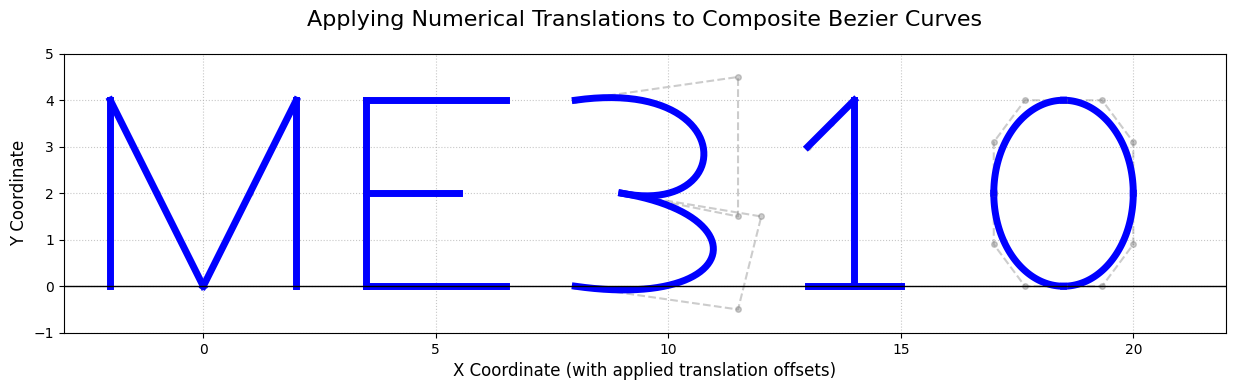

In [ ]:
# The Typography Dictionary for "ME310"
font_dictionary_ourCourse = {
    'M': [
        [[-2.0, 0.0], [-2.0, 2.0], [-2.0, 4.0], [-2.0, 4.0]],
        [[-2.0, 4.0], [-1.0, 2.0], [0.0, 0.0], [0.0, 0.0]],
        [[0.0, 0.0], [1.0, 2.0], [2.0, 4.0], [2.0, 4.0]],
        [[2.0, 4.0], [2.0, 2.0], [2.0, 0.0], [2.0, 0.0]]
    ],
    'E': [
        [[0.0, 4.0], [0.0, 2.0], [0.0, 2.0], [0.0, 0.0]],
        [[0.0, 4.0], [1.0, 4.0], [2.0, 4.0], [3.0, 4.0]],
        [[0.0, 2.0], [1.0, 2.0], [1.5, 2.0], [2.0, 2.0]],
        [[0.0, 0.0], [1.0, 0.0], [2.0, 0.0], [3.0, 0.0]]
    ],
    '3': [
        [[0.0, 4.0], [3.5, 4.5], [3.5, 1.5], [1.0, 2.0]],
        [[1.0, 2.0], [4.0, 1.5], [3.5, -0.5], [0.0, 0.0]]
    ],
    '1': [
        [[-1.0, 3.0], [-0.5, 3.5], [0.0, 4.0], [0.0, 4.0]],
        [[0.0, 4.0], [0.0, 2.0], [0.0, 2.0], [0.0, 0.0]],
        [[-1.0, 0.0], [0.0, 0.0], [0.0, 0.0], [1.0, 0.0]]
    ],
    '0': [
        [[1.5, 4.0], [2.33, 4.0], [3.0, 3.1], [3.0, 2.0]],
        [[3.0, 2.0], [3.0, 0.9], [2.33, 0.0], [1.5, 0.0]],
        [[1.5, 0.0], [0.67, 0.0], [0.0, 0.9], [0.0, 2.0]],
        [[0.0, 2.0], [0.0, 3.1], [0.67, 4.0], [1.5, 4.0]]
    ]
}

# Define the word layout and "kerning" (X-axis translation)
# Format: ('Letter', X_Offset_Value)
word_layout = [
    ('M', 0.0),
    ('E', 3.5),
    ('3', 8.0),
    ('1', 14.0),
    ('0', 17.0)
]

# Plotting the final word
plt.figure(figsize=(15, 5)) # Wide figure to fit the whole word

# Loop through each letter in our layout
for letter, x_offset in word_layout:
    segments = font_dictionary_ourCourse[letter]

    # Loop through each Bezier curve segment of the current letter
    for segment in segments:
        # Extract the base control points
        P0, P1, P2, P3 = np.array(segment)

        # Apply the linear translation (shift the X coordinates)
        P0[0] += x_offset
        P1[0] += x_offset
        P2[0] += x_offset
        P3[0] += x_offset

        # Generate the smooth curve points
        curve_x, curve_y = cubic_bezier(P0, P1, P2, P3, 50)

        # Extract the translated control polygon for visualization
        poly_x = [P0[0], P1[0], P2[0], P3[0]]
        poly_y = [P0[1], P1[1], P2[1], P3[1]]

        # Plot the control polygon (faint dashed lines)
        plt.plot(poly_x, poly_y, color='gray', linestyle='--', marker='o',
                 markersize=4, alpha=0.4)

        # Plot the final Bezier curve (solid blue line)
        plt.plot(curve_x, curve_y, 'b-', linewidth=5)

# Formatting the plot
plt.title("Applying Numerical Translations to Composite Bezier Curves", fontsize=16, pad=20)
plt.xlim(-3, 22)
plt.ylim(-1, 5)
plt.gca().set_aspect('equal', adjustable='box') # Ensures X and Y axes are to scale
plt.grid(True, linestyle=':', alpha=0.7)
plt.axhline(0, color='black', linewidth=1) # Baseline
plt.xlabel("X Coordinate (with applied translation offsets)", fontsize=12)
plt.ylabel("Y Coordinate", fontsize=12)

plt.show()

## How Professional Fonts Actually Work

Now that we understand the fundamentals, let's examine how real fonts are constructed. All modern digital fonts, including the one you're reading right now, use Bezier curves to define every letter shape.

### Font File Formats and Bezier Curves

Professional font formats use two main types of curves:
- **TrueType fonts (.ttf)**: Use **quadratic Bezier curves** (3 control points: $P_0$, $P_1$, $P_2$)
- **PostScript/OpenType fonts (.otf)**: Use **cubic Bezier curves** (4 control points: $P_0$, $P_1$, $P_2$, $P_3$)

Each letter is stored as a collection of Bezier curve segments with precise control point coordinates. This mathematical representation allows fonts to scale perfectly to any size without losing quality—a 12pt letter uses the *exact same mathematical formula* as a 120pt billboard letter!.

### Case Study: Times New Roman Letter "T"

The code below visualizes actual font data extracted from **Times New Roman**, one of the most widely used typefaces in the world. This dataset comes from Sauer's *Numerical Analysis* textbook and shows the letter "T" defined by **16 cubic Bezier curves**.

Notice how the professional font includes intricate details like **serifs** (the decorative feet and caps on letters). These elegant flourishes that make the font distinctive are all created using carefully positioned control points.

**The Two Views:**
- **Left plot**: Shows all 16 individual curves with their control polygons in different colors—this is what numerical analysts and font designers see
- **Right plot**: Shows the final rendered letter as a solid black shape—this is what you see when you read text

Professional typography is numerical methods in action. Font designers are essentially choosing control points to achieve aesthetic goals, and computers use the Bezier formulas you learned above to render beautiful, scalable text.

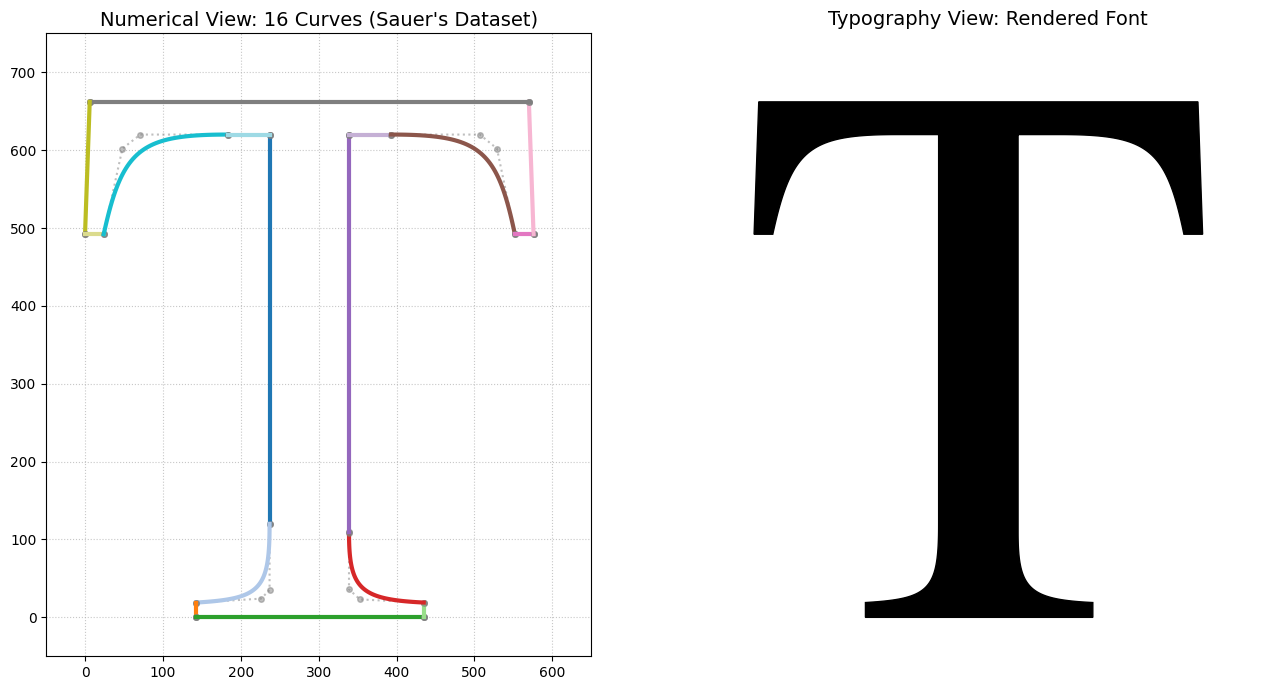

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mathematical function for Cubic Bezier
def cubic_bezier(P0, P1, P2, P3, num_points=50):
    t = np.linspace(0, 1, num_points)
    x = ((1-t)**3 * P0[0] + 3*(1-t)**2 * t * P1[0] + 3*(1-t) * t**2 * P2[0] + t**3 * P3[0])
    y = ((1-t)**3 * P0[1] + 3*(1-t)**2 * t * P1[1] + 3*(1-t) * t**2 * P2[1] + t**3 * P3[1])
    return x, y

# The exact "Times New Roman" dataset from Sauer's Numerical Analysis book
# 16 Bezier curves forming the letter 'T'
sauer_T_curves = [
    [[237, 620], [237, 620], [237, 120], [237, 120]], # 1. Stem left edge
    [[237, 120], [237, 35],  [226, 24],  [143, 19]],  # 2. Left bottom serif curve
    [[143, 19],  [143, 19],  [143, 0],   [143, 0]],   # 3. Left bottom serif edge
    [[143, 0],   [143, 0],   [435, 0],   [435, 0]],   # 4. Bottom flat edge
    [[435, 0],   [435, 0],   [435, 19],  [435, 19]],  # 5. Right bottom serif edge
    [[435, 19],  [353, 23],  [339, 36],  [339, 109]], # 6. Right bottom serif curve
    [[339, 109], [339, 108], [339, 620], [339, 620]], # 7. Stem right edge
    [[339, 620], [339, 620], [393, 620], [393, 620]], # 8. Under right crossbar
    [[393, 620], [507, 620], [529, 602], [552, 492]], # 9. Right top serif curve down
    [[552, 492], [552, 492], [576, 492], [576, 492]], # 10. Right top serif outer edge
    [[576, 492], [576, 492], [570, 662], [570, 662]], # 11. Right top serif top edge
    [[570, 662], [570, 662], [6,   662], [6,   662]], # 12. Top flat crossbar
    [[6,   662], [6,   662], [0,   492], [0,   492]], # 13. Left top serif top edge
    [[0,   492], [0,   492], [24,  492], [24,  492]], # 14. Left top serif outer edge
    [[24,  492], [48,  602], [71,  620], [183, 620]], # 15. Left top serif curve down
    [[183, 620], [183, 620], [237, 620], [237, 620]]  # 16. Under left crossbar to start
]

# Create a side-by-side plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
colors = plt.cm.tab20(np.linspace(0, 1, len(sauer_T_curves)))

# Arrays to hold the entire outer boundary for filling the shape
full_outline_x = []
full_outline_y = []

# ==========================================
# SUBPLOT 1: The Numerical Methods View
# ==========================================
for i, segment in enumerate(sauer_T_curves):
    P0, P1, P2, P3 = np.array(segment)

    # Generate the curve points
    curve_x, curve_y = cubic_bezier(P0, P1, P2, P3)

    # Append to our full outline for Subplot 2
    if i == 0:
        full_outline_x.extend(curve_x)
        full_outline_y.extend(curve_y)
    else:
        full_outline_x.extend(curve_x[1:])
        full_outline_y.extend(curve_y[1:])

    # Plot control polygon (dashed lines)
    poly_x = [P0[0], P1[0], P2[0], P3[0]]
    poly_y = [P0[1], P1[1], P2[1], P3[1]]
    ax1.plot(poly_x, poly_y, color='gray', linestyle=':', marker='o',
             markersize=4, alpha=0.5)

    # Plot the curve segment (solid, colored line)
    ax1.plot(curve_x, curve_y, color=colors[i], linewidth=3,
             label=f'Curve {i+1}')

ax1.set_title(f"Numerical View: 16 Curves", fontsize=14)
# Adjusting limits
ax1.set_xlim(-50, 650)
ax1.set_ylim(-50, 750)
ax1.set_aspect('equal', adjustable='box')
ax1.grid(True, linestyle=':', alpha=0.7)

# ==========================================
# SUBPLOT 2: The Typography View
# ==========================================
# Use Matplotlib's fill function to render the closed shape
ax2.fill(full_outline_x, full_outline_y, color='black')

ax2.set_title("Typography View: Rendered Font", fontsize=14)
ax2.set_xlim(-50, 650)
ax2.set_ylim(-50, 750)
ax2.set_aspect('equal', adjustable='box')
ax2.axis('off')

plt.tight_layout()
plt.show()

## Extracting Real Font Data: From TTF Files to Bezier Curves

### What are TTF Files?

**TrueType Font (.ttf)** files are binary files that contain the complete mathematical definition of every character in a font. They store:
- **Glyph outlines**: Bezier curve control points for each letter, number, and symbol
- **Metrics**: Character widths, heights, and spacing information (kerning)
- **Hinting instructions**: Rules for rendering at small sizes on low-resolution screens
- **Metadata**: Font name, designer, copyright, version, etc.

### Where to Find TTF Files on Your Computer

Every operating system comes with font files pre-installed:
- **macOS**: `/System/Library/Fonts/` or `/Library/Fonts/`
- **Windows**: `C:\Windows\Fonts\`
- **Linux**: `/usr/share/fonts/`

Times New Roman (the font we're using) can typically be found as `Times.ttf` or `times.ttf` or as a *collection* as `Times.ttc` in these directories.

### How the Dataset Was Extracted

The dataset used in this notebook was extracted by:
1. Locating the Times New Roman `.ttf` file from the system fonts library
2. Using Python libraries (like `fontTools` or `freetype`) to parse the binary TTF file structure
3. Extracting the **quadratic Bezier curve** control points for each glyph (character)
4. Converting the coordinates from the font's internal coordinate system to plottable values
5. Storing the data as a Python dictionary for easy access

### Accessing the Pre-Extracted Dataset

To save you the complexity of parsing binary font files, the extracted Times New Roman dataset has been made available in a **GitHub Gist**. The cell below downloads this dataset so you can immediately start working with real professional font data!

In [8]:
# Download the extracted Times New Roman dataset from your GitHub Gist
!wget -q -O times_new_roman_dataset.py "https://gist.github.com/ata23kan/344279b39aabf0ec6a6663de825836dd/raw"

print("Times New Roman dataset successfully loaded into the environment!")

Times New Roman dataset successfully loaded into the environment!


## Writing Text with Professional Fonts

Now we'll use the real Times New Roman dataset to render "ME310" as a solid, publication-ready font. This code uses **matplotlib's PathPatch** to fill the shapes defined by our Bezier curves, creating the professional appearance you'd see in any document.

### Understanding Kerning

**Kerning** is the spacing between letters. In the code below, `letter_padding = 150` controls this spacing. Professional typography requires careful kerning because:
- Too little spacing: letters overlap and become unreadable
- Too much spacing: text looks disconnected and awkward (e.g., "M  E  3  1  0")
- Optimal spacing: depends on letter combinations—pairs like "AV" or "To" need tighter spacing than "HI"

**Try This**: After running the cell, modify the `letter_padding` value in the code:
- Set it to `50` → Letters get cramped
- Set it to `300` → Letters spread far apart
- Find the value that looks most visually balanced to you!

This is exactly what graphic designers do when creating logos, posters, and professional layouts—using mathematics to achieve aesthetic perfection.

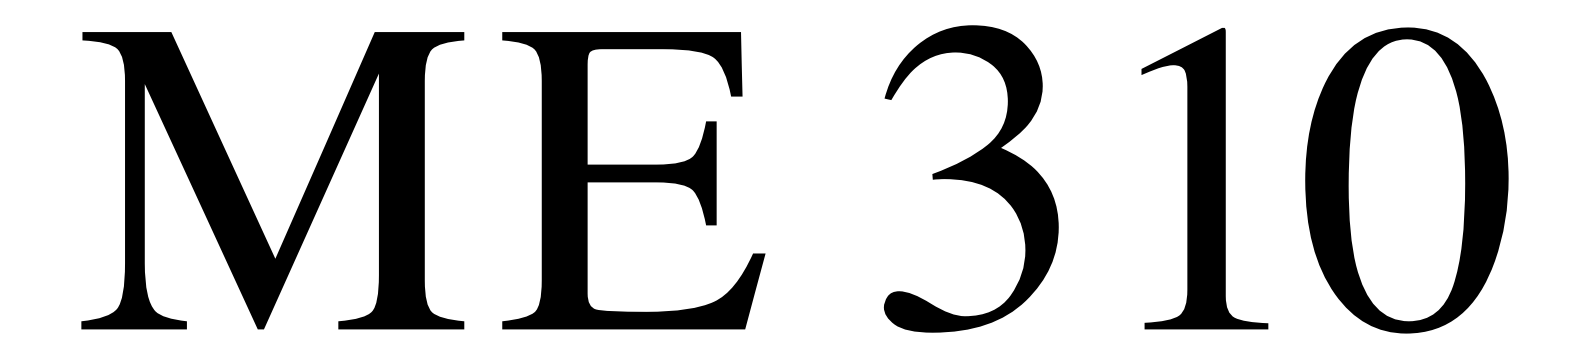

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as mpatches

# Import the dataset from your downloaded Gist
from times_new_roman_dataset import font_data

# Define the word you want to spell
word_to_spell = "ME 310"

# Set up the plot
fig, ax = plt.subplots(figsize=(16, 5))

# The Layout Engine (Dynamic Kerning & Path Generation)
current_x_offset = 0
letter_padding = 150  # Space between letters

for char in word_to_spell:
    # Handle space characters by adding empty spacing
    if char == ' ':
        current_x_offset += 2*letter_padding
        continue
    
    if char not in font_data:
        print(f"Warning: Character '{char}' not found in dataset.")
        continue

    segments = font_data[char]
    max_x_for_this_letter = 0

    # We will store the path data for matplotlib
    vertices = []
    codes = []

    # Loop through every quadratic curve in the letter
    for segment in segments:
        P0, P1, P2 = np.array(segment, dtype=float)

        # Apply the layout translation (shift X coordinates)
        P0[0] += current_x_offset
        P1[0] += current_x_offset
        P2[0] += current_x_offset

        # Track the width for kerning
        max_x_for_this_letter = max(max_x_for_this_letter, P0[0], P1[0], P2[0])

        # --- PATH CONSTRUCTION LOGIC ---
        # If this is the first point, or if the current curve doesn't perfectly
        # connect to the end of the last curve, we must "Move" the pen to start a new loop.
        if not vertices or (P0[0] != vertices[-1][0] or P0[1] != vertices[-1][1]):
            vertices.append(P0)
            codes.append(mpath.Path.MOVETO)

        # Add the control point (P1) and endpoint (P2)
        vertices.extend([P1, P2])
        # Tell matplotlib these two points define a Quadratic Bezier (CURVE3)
        codes.extend([mpath.Path.CURVE3, mpath.Path.CURVE3])

    # Create the geometric path and patch it onto the plot as a solid shape
    if vertices:
        path = mpath.Path(vertices, codes)
        # facecolor='black' fills the inside. edgecolor='none' removes the outline.
        patch = mpatches.PathPatch(path, facecolor='black', edgecolor='none')
        ax.add_patch(patch)

    # Update the offset for the next letter
    current_x_offset = max_x_for_this_letter + letter_padding

# Formatting the plot
ax.autoscale() # Force the axes to fit our newly added patches
ax.set_aspect('equal', adjustable='box')

# Hide the axes for a clean typographic look
plt.axis('off')

plt.tight_layout()
plt.show()